# ___Phylogenetic analysis of the FRED 4.0 subset___
----------------------

In [1]:
print(R.version$version.string)

[1] "R version 4.6.0 (2026-04-24 ucrt)"


In [66]:
suppressPackageStartupMessages({
    library("ape")
    library("phytools")
    library("U.PhyloMaker")
    library("phylolm")
    library("geiger")
    library("Rphylopars")
    library("readxl")
})

In [67]:
packageVersion("phytools")

[1] '2.5.2'

In [3]:
packageVersion("U.PhyloMaker")

[1] '0.1.0'

In [4]:
packageVersion("phylolm")

[1] '2.7.0'

In [5]:
packageVersion("Rphylopars")

[1] '0.3.10'

In [6]:
packageVersion("geiger")

[1] '2.0.11'

## ___1. Phylogeny construction___
---------------------------

In [ ]:
megatree <- ape::read.tree("../../data/chapter2/uphylomaker/GBOTB.extended.TPL.tre") # TPL megatree
# the order info in the FRED 4.0 subset dataset wasn't cross checked!!!!
traits <- read.csv("../../data/chapter2/FRED/subsets/final") # FRED 4.0 subset with names reconciled with the megatree by hand
# this does not need programmatic name reconciliations
traits$binominal <- gsub(traits$binominal, pattern = ' ', replacement = '_')
synonyms <- read.csv("../../data/chapter2/wcvp/synonyms.csv") # WCVP synonyms

In [7]:
#---------------------------
# phylogeney construction
#---------------------------

# species, genus, family, species.relative, genus.relative
species_list <- data.frame(species = traits$binominal, genus = traits$F01286, family = NA, species.relative = NA, genus.relative = NA)
genus_list <- data.frame(genus = traits$F01286, family = traits$F01289) 
phy <- U.PhyloMaker::phylo.maker(sp.list = species_list, gen.list = genus_list, tree = megatree)

In [8]:
ape::write.tree(phy = phy$phylo, file = "../../data/chapter2/uphylomaker/FRED4_1301_species.tre")

In [22]:
stopifnot(all(traits[match(phy$phylo$tip.label, traits$binominal), ]$binominal == phy$phylo$tip.label))
traits <- traits[match(phy$phylo$tip.label, traits$binominal), ]
write.csv(traits, "../../data/chapter2/FRED/subsets/final_name_matched.csv", row.names = FALSE)

## ___2. Phylogenetic signal and pairwise relationships___
---------------------------

In [7]:
GEIGER_FITCONTINUOUS_MODEL_OPTIONS <- c("BM", "OU", "EB", "rate_trend", "lambda", "kappa", "delta", "mean_trend", "white")
PHYLOLM_PHYLOLM_MODEL_OPTIONS <- c("BM", "OUrandomRoot", "OUfixedRoot", "lambda", "kappa", "delta", "EB", # "trend", - "trend" option is problematic for ultrametric trees
                                   "GC")

In [8]:
# this phylogeny needs to be fully bifurcating with no polytomies
tree <- ape::read.tree("../../data/chapter2/uphylomaker/FRED4_1301.tre") # the phylogeny of the 1301 FRED 4.0 subset species

In [9]:
if(!ape::is.binary(tree)) tree <- ape::multi2di(tree, random = FALSE) # split polytomies into binary 0 length branches

# make the phylogeny completely bifurcating by replacing 0 length branches
tree$edge.length[tree$edge.length <= 0] <- rnorm(n = sum(tree$edge.length == 0), mean = 1e-6, sd = 1e-8) # replace the 0 length edges with random noise
stopifnot(!sum(tree$edge.length <= 0)) # no more 0 length branches

# this must be done after altering the branch lengths
if (!ape::is.ultrametric(tree)) tree <- phytools::force.ultrametric(tree = tree, method = "extend") # this needs to be done after replacing the 0 length branches with small non zero noise

stopifnot(ape::is.binary(tree) && ape::is.ultrametric(tree))

traits <- read.csv("../../data/chapter2/FRED/subsets/name_matched_FRED4_1301.csv", row.names = "binominal") # we need the binominal names as row names for phylolm::phylolm()

# repeat the taxonomic corrections
# traits[traits$F01286 %in% c("Parablechnum", "Lomaria", "Blechnopsis"), "F01286"] = "Blechnum"
# traits[traits$F01286 == "Pseudodiphasium", "F01286"] = "Lycopodium"
# traits[traits$F01286 %in% c("Richetia", "Rubroshorea"), "F01286"] = "Shorea"

# traits["binominal"] <- paste0(traits$F01286, '_', traits$F01287)
# stopifnot(length(traits$binominal)==length(tree$tip.label))
# stopifnot(sum(tree$tip.label %in% traits$binominal) == length(tree$tip.label))
# traits <- traits[match(tree$tip.label, traits$binominal), ] # name matching the dataset and the phylogeny

stopifnot(all(tree$tip.label==traits$binominal)) # the current traits dataset has already been name matched with the phylogeny!!!!!!!!

***************************************************************
*                          Note:                              *
*    force.ultrametric does not include a formal method to    *
*    ultrametricize a tree & should only be used to coerce    *
*   a phylogeny that fails is.ultrametric due to rounding --  *
*    not as a substitute for formal rate-smoothing methods.   *
***************************************************************


In [10]:
head(traits)

,F01286,F01289,F00679,F00679_se,F00727,F00727_se,F00709,F00709_se,state,state_source,synonym
,<chr>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>,<chr>,<chr>
Ratibida_pinnata,Ratibida,Asteraceae,-0.8209806,NA,4.025352,NA,-2.120264,NA,AM,"(Soudzilovskaia et al., 2020)","('Lepachys pinnata', 'Rudbeckia pinnata', 'Helianthus pinnatus', 'Obeliscaria pinnata')"
Heliopsis_helianthoides,Heliopsis,Asteraceae,-0.9675840,NA,4.158883,NA,-1.966113,NA,AM,"(Brundrett and Tedersoo, 2018)","('Buphthalmum helianthoides',)"
Liatris_aspera,Liatris,Asteraceae,-0.7985077,NA,4.382027,NA,-2.525729,NA,AM,(Maherali et. al. 2016),"('Lacinaria scariosa var. aspera', 'Lacinaria aspera')"
Arnica_sororia,Arnica,Asteraceae,-1.4134600,NA,4.342257,NA,-1.203973,NA,AM,"(Soudzilovskaia et al., 2020)","('Arnica fulgens var. sororia',)"
Arnica_fulgens,Arnica,Asteraceae,-0.6627150,NA,2.765172,NA,-1.124452,NA,AM,(Maherali et. al. 2016),"('Arnica montana var. fulgens',)"
Hymenoxys_richardsonii,Hymenoxys,Asteraceae,-1.2644308,NA,4.235371,NA,-1.460061,NA,AM,"(Soudzilovskaia et al., 2020)","('Picradenia richardsonii', 'Actinea richardsonii', 'Actinella richardsonii')"


In [63]:
# the tutorial uses the R library phylolm
# nlme::gls requires a correlation matrix - ape provides only limited options (Brownian, Bloomberg, Pagel et.c.) for this

suppressWarnings(
    rbind(
        SRL.RD = mapply(PHYLOLM_PHYLOLM_MODEL_OPTIONS, FUN = function (m) phylolm::phylolm(F00727 ~ F00679, data = traits, model = m, phy = tree)$aic), # SRL ~ RD
        RD.SRL = mapply(PHYLOLM_PHYLOLM_MODEL_OPTIONS, FUN = function (m) phylolm::phylolm(F00679 ~ F00727, data = traits, model = m, phy = tree)$aic) # RD ~ SRL
    )
)

,BM,OUrandomRoot,OUfixedRoot,lambda,kappa,delta,EB,GC
SRL.RD,4340.725,2917.8101,2917.8101,2342.3040,2532.9360,4237.162,4342.725,3036.2211
RD.SRL,2002.748,661.4962,661.4962,169.3322,405.0684,1901.315,2004.748,938.3773


In [64]:
suppressWarnings(
    rbind(
        SRL.RTD = mapply(PHYLOLM_PHYLOLM_MODEL_OPTIONS, FUN = function (m) phylolm::phylolm(F00727 ~ F00709, data = traits, model = m, phy = tree)$aic), # SRL ~ RTD
        RTD.SRL = mapply(PHYLOLM_PHYLOLM_MODEL_OPTIONS, FUN = function (m) phylolm::phylolm(F00709 ~ F00727, data = traits, model = m, phy = tree)$aic) # RTD ~ SRL
    )
)

,BM,OUrandomRoot,OUfixedRoot,lambda,kappa,delta,EB,GC
SRL.RTD,4598.274,3506.664,3506.664,3016.570,3177.735,4499.339,4600.274,3645.258
RTD.SRL,3157.692,1992.819,1992.819,1544.616,1733.519,3058.137,3159.692,2177.964


In [65]:
suppressWarnings(
    rbind(
        RTD.RD = mapply(PHYLOLM_PHYLOLM_MODEL_OPTIONS, FUN = function (m) phylolm::phylolm(F00709 ~ F00679, data = traits, model = m, phy = tree)$aic), # RTD ~ RD
        RD.RTD = mapply(PHYLOLM_PHYLOLM_MODEL_OPTIONS, FUN = function (m) phylolm::phylolm(F00679 ~ F00709, data = traits, model = m, phy = tree)$aic) # RD ~ RTD
    )
)

,BM,OUrandomRoot,OUfixedRoot,lambda,kappa,delta,EB,GC
RTD.RD,3754.571,2467.833,2467.833,1940.750,2097.047,3652.552,3756.571,2547.834
RD.RTD,2857.176,1725.364,1725.364,1239.566,1413.929,2757.907,2859.176,1917.285


In [11]:
table(traits$state)


   AM   EcM EcMAM   ErM    NM  NMAM 
 1097   121    20     9    16    38 

## ___Pairwise correlations with all the records___
------------------------------

In [59]:
#------------
# SRL & RD
#------------

lmod <- lm(F00727 ~ F00679, data = traits)
plmod <- phylolm::phylolm(F00727 ~ F00679, data = traits, model = "OUfixedRoot", phy = tree, lower.bound = list(alpha=1e-10), upper.bound = list(alpha=10))

options(repr.plot.width = 6, repr.plot.height = 6, repr.plot.res = 200)

png(filename = "../../plots/SRL-RD_FRED4.png", width = 10, height = 10, units = "in", res = 500)
plot(F00727 ~ F00679, data = traits, xlab = "RD", ylab = "SRL", mgp=c(1.85, 0.7, 0), frame.plot = TRUE)
abline(lmod, col = "red")
abline(plmod, col = "blue")
dev.off()

pdf 
  2

In [53]:
summary(lmod)


Call:
lm(formula = F00727 ~ F00679, data = traits)

Residuals:
     Min       1Q   Median       3Q      Max 
-2.85163 -0.43048 -0.06405  0.34489  3.06180 

Coefficients:
            Estimate Std. Error t value Pr(>|t|)    
(Intercept)  1.67507    0.04464   37.53   <2e-16 ***
F00679      -1.88414    0.04391  -42.91   <2e-16 ***
---
Signif. codes:  0 '***' 0.001 '**' 0.01 '*' 0.05 '.' 0.1 ' ' 1

Residual standard error: 0.7354 on 1299 degrees of freedom
Multiple R-squared:  0.5863,	Adjusted R-squared:  0.586 
F-statistic:  1841 on 1 and 1299 DF,  p-value: < 2.2e-16


In [54]:
summary(plmod)


Call:
phylolm::phylolm(formula = F00727 ~ F00679, data = traits, phy = tree, 
    model = "OUfixedRoot", lower.bound = list(alpha = 1e-10), 
    upper.bound = list(alpha = 10))

   AIC logLik 
  2633  -1312 

Raw residuals:
     Min       1Q   Median       3Q      Max 
-2.83845 -0.38288 -0.01639  0.39160  3.12000 

Mean tip height: 400.7877
Parameter estimate(s) using ML:
alpha: 0.5129212
sigma2: 0.4730747 

Coefficients:
             Estimate    StdErr t.value   p.value    
(Intercept)  1.606749  0.041375  38.834 < 2.2e-16 ***
F00679      -1.908999  0.040121 -47.582 < 2.2e-16 ***
---
Signif. codes:  0 '***' 0.001 '**' 0.01 '*' 0.05 '.' 0.1 ' ' 1

R-squared: 0.6354	Adjusted R-squared: 0.6351 

Note: p-values and R-squared are conditional on alpha=0.5129212.

In [60]:
#------------
# SRL & RTD
#------------

lmod <- lm(F00727 ~ F00709, data = traits)
plmod <- phylolm::phylolm(F00727 ~ F00709, data = traits, model = "OUfixedRoot", phy = tree, lower.bound = list(alpha=1e-10), upper.bound = list(alpha=10))

png(filename = "../../plots/SRL-RTD_FRED4.png", width = 10, height = 10, units = "in", res = 500)
plot(F00727 ~ F00709, data = traits, xlab = "RTD", ylab = "SRL", mgp=c(1.85, 0.7, 0))
abline(lmod, col = "red")
abline(plmod, col = "blue")
dev.off()

pdf 
  2

In [56]:
summary(lmod)


Call:
lm(formula = F00727 ~ F00709, data = traits)

Residuals:
     Min       1Q   Median       3Q      Max 
-2.03060 -0.69552 -0.05758  0.61428  2.88374 

Coefficients:
            Estimate Std. Error t value Pr(>|t|)    
(Intercept)  2.00493    0.05812   34.50   <2e-16 ***
F00709      -1.03227    0.03920  -26.33   <2e-16 ***
---
Signif. codes:  0 '***' 0.001 '**' 0.01 '*' 0.05 '.' 0.1 ' ' 1

Residual standard error: 0.9233 on 1299 degrees of freedom
Multiple R-squared:  0.348,	Adjusted R-squared:  0.3475 
F-statistic: 693.4 on 1 and 1299 DF,  p-value: < 2.2e-16


In [57]:
summary(plmod)


Call:
phylolm::phylolm(formula = F00727 ~ F00709, data = traits, phy = tree, 
    model = "OUfixedRoot", lower.bound = list(alpha = 1e-10), 
    upper.bound = list(alpha = 10))

   AIC logLik 
  3444  -1718 

Raw residuals:
     Min       1Q   Median       3Q      Max 
-2.01231 -0.71121 -0.08481  0.59784  2.83466 

Mean tip height: 400.7877
Parameter estimate(s) using ML:
alpha: 0.2325946
sigma2: 0.4217697 

Coefficients:
             Estimate    StdErr t.value   p.value    
(Intercept)  2.085097  0.061405  33.957 < 2.2e-16 ***
F00709      -0.987418  0.041060 -24.048 < 2.2e-16 ***
---
Signif. codes:  0 '***' 0.001 '**' 0.01 '*' 0.05 '.' 0.1 ' ' 1

R-squared: 0.3081	Adjusted R-squared: 0.3075 

Note: p-values and R-squared are conditional on alpha=0.2325946.

In [64]:
#------------
# RD & RTD
#------------

lmod <- lm(F00709 ~ F00679, data = traits)
plmod <- phylolm::phylolm(F00709 ~ F00679, data = traits, model = "OUfixedRoot", phy = tree, lower.bound = list(alpha=1e-10), upper.bound = list(alpha=10))

png(filename = "../../plots/RTD-RD_FRED4.png", width = 10, height = 10, units = "in", res = 500)
plot(F00709 ~ F00679, data = traits, xlab = "RD", ylab = "RTD", mgp=c(1.85, 0.7, 0))
abline(lmod, col = "red")
abline(plmod, col = "blue")
dev.off()

pdf 
  2

In [65]:
summary(lmod)


Call:
lm(formula = F00709 ~ F00679, data = traits)

Residuals:
     Min       1Q   Median       3Q      Max 
-2.63557 -0.35487  0.08587  0.44516  1.88227 

Coefficients:
            Estimate Std. Error t value Pr(>|t|)    
(Intercept) -1.30082    0.03965 -32.807   <2e-16 ***
F00679       0.03337    0.03901   0.855    0.392    
---
Signif. codes:  0 '***' 0.001 '**' 0.01 '*' 0.05 '.' 0.1 ' ' 1

Residual standard error: 0.6533 on 1299 degrees of freedom
Multiple R-squared:  0.000563,	Adjusted R-squared:  -0.0002064 
F-statistic: 0.7317 on 1 and 1299 DF,  p-value: 0.3925


In [66]:
summary(plmod)


Call:
phylolm::phylolm(formula = F00709 ~ F00679, data = traits, phy = tree, 
    model = "OUfixedRoot", lower.bound = list(alpha = 1e-10), 
    upper.bound = list(alpha = 10))

   AIC logLik 
  2394  -1193 

Raw residuals:
     Min       1Q   Median       3Q      Max 
-2.66411 -0.38193  0.04859  0.41283  1.86429 

Mean tip height: 400.7877
Parameter estimate(s) using ML:
alpha: 0.5120724
sigma2: 0.3931256 

Coefficients:
             Estimate    StdErr  t.value p.value    
(Intercept) -1.249621  0.037749 -33.1035  <2e-16 ***
F00679       0.053618  0.036603   1.4648  0.1432    
---
Signif. codes:  0 '***' 0.001 '**' 0.01 '*' 0.05 '.' 0.1 ' ' 1

R-squared: 0.001649	Adjusted R-squared: 0.0008806 

Note: p-values and R-squared are conditional on alpha=0.5120724.

In [120]:
# evern after accounting for phylogenetic relatedness, RD ~ SRL and SRL ~ RTD trait pairs show significant relationships
# so, next step, calculate how much phylogenetic signal is present in our continuous traits?? because the above could be a result of our dataset having little to no phylogenetic signal???

In [27]:
# INVESTIGATE THE PHYLOGENETIC SIGNAL IN THE CONTINUOUS TRAITS
# lambda method is best suited for detecting phylogenetic signals lesser (weaker) than that's expected under a BM model - not good for signals stronger than that of a BM model
# lambda < 1 corresponds to less phylogenetic signal than expected under a BM model

# all the continuous traits have already been log transformed
physig_srl <- phytools::phylosig(tree = tree, method = "lambda", x = setNames(traits$F00727, nm = rownames(traits)), test = TRUE)
physig_rd <- phytools::phylosig(tree = tree, method = "lambda", x = setNames(traits$F00679, nm = rownames(traits)), test = TRUE)
physig_rtd <- phytools::phylosig(tree = tree, method = "lambda", x = setNames(traits$F00709, nm = rownames(traits)), test = TRUE)

In [ ]:
# all the three traits have pretty similar lambda values and all of them are closer to 1.0 than to 0.0
# this tells us that we can reject the null hypothesis that lambda = 0 (with reference to the p values)
# LR stands for Likelihood Ratio

In [28]:
physig_srl


Phylogenetic signal lambda : 0.833651 
logL(lambda) : -1702.85 
LR(lambda=0) : 623.519 
P-value (based on LR test) : 1.2835e-137 


In [29]:
physig_rd


Phylogenetic signal lambda : 0.828158 
logL(lambda) : -616.319 
LR(lambda=0) : 466.128 
P-value (based on LR test) : 2.23079e-103 


In [30]:
physig_rtd


Phylogenetic signal lambda : 0.831478 
logL(lambda) : -966.91 
LR(lambda=0) : 630.01 
P-value (based on LR test) : 4.97377e-139 


In [44]:
# now test for the hypothesis that lambda = 1 (the phylogenetic signal observed is no more significant than what could be generated by a stochastic BM process)
# the $lik attribute of a phylosig object is the function used for its optimization

# likelihood of lambda = 1 is physig_srl$lik(1.00)
# then compare it to the MLE of lambda
lr_srl <- -2 * (physig_srl$lik(1.00) - physig_srl$logL) # page 97 - Phylogenetic Comparative Methods in R

# then compute the p statistic for our LR by comparing it to a chi squared dist with 1 degrees of freedom
pchisq(q = lr_srl, df = 1, lower.tail = FALSE) # p = 0, so we can reject the null hypothesis, which in this case is lambda = 1

[1] 0

In [45]:
# for RTD
pchisq(q = -2 * (physig_rtd$lik(1.00) - physig_rtd$logL), df = 1, lower.tail = FALSE)

[1] 0

In [46]:
# for RD
pchisq(q = -2 * (physig_rd$lik(1.00) - physig_rd$logL), df = 1, lower.tail = FALSE)

[1] 0

In [ ]:
# in conclusion; lambda != 1 and lambda != 0 for all the three continuous traits according to Pagel's lambda test

In [70]:
# now do Bloomberg's K test for all the three traits => most papers report both not just one
# Bloomberk's K is a normalized ratio of comparing variance among clades to variance within clades
# for a simple BM model of evolution, Bloomberg's K must be 1.00

physig_srl <- phytools::phylosig(tree = tree, method = "K", x = setNames(traits$F00727, nm = rownames(traits)), test = TRUE, nsim = 10000)
physig_rd <- phytools::phylosig(tree = tree, method = "K", x = setNames(traits$F00679, nm = rownames(traits)), test = TRUE, nsim = 10000)
physig_rtd <- phytools::phylosig(tree = tree, method = "K", x = setNames(traits$F00709, nm = rownames(traits)), test = TRUE, nsim = 10000)

In [71]:
physig_rd


Phylogenetic signal K : 0.0234281 
P-value (based on 10000 randomizations) : 1e-04 


In [72]:
physig_srl


Phylogenetic signal K : 0.0228481 
P-value (based on 10000 randomizations) : 1e-04 


In [73]:
physig_rtd


Phylogenetic signal K : 0.0319059 
P-value (based on 10000 randomizations) : 1e-04 


In [ ]:
# in our case, all the three traits show a K that is less than expected from a BM model of evolution

In [47]:
# for an explanation on non BM models - https://lukejharmon.github.io/pcm/chapter6_beyondbm/
# page 100 of Phylogenetic Comparative Methods in R
# PAY ATTENTION TO THE WARNING MESSAGES HERE!!!!!!!!

tm <- Sys.time()

SRL_model_fits <- list()
RD_model_fits <- list()
RTD_model_fits <- list()

for (m in GEIGER_FITCONTINUOUS_MODEL_OPTIONS) {
    SRL_model_fits[[m]] <- geiger::fitContinuous(phy = tree, dat = traits["F00727"], model = m)
    RD_model_fits[[m]] <- geiger::fitContinuous(phy = tree, dat = traits["F00679"], model = m)
    RTD_model_fits[[m]] <- geiger::fitContinuous(phy = tree, dat = traits["F00709"], model = m)
    print(paste0("all ", m, " fits done!"))
}

tm <- Sys.time() - tm

save(SRL_model_fits, RD_model_fits, RTD_model_fits, file = "../../data/chapter2/rdata/SRL_RD_RTD_geiger_fitContinuous.RData")

[1] "all BM fits done!"
[1] "all OU fits done!"


Warning message in geiger::fitContinuous(phy = tree, dat = traits["F00679"], model = m):
"
Parameter estimates appear at bounds:
	a"


[1] "all EB fits done!"
[1] "all rate_trend fits done!"
[1] "all lambda fits done!"
[1] "all kappa fits done!"
[1] "all delta fits done!"
[1] "all mean_trend fits done!"
[1] "all white fits done!"


In [48]:
tm # not bad at all :)

Time difference of 6.48128 mins

In [50]:
# inspect the EB models 

SRL_model_fits[["EB"]]$opt # alpha is near zero - in this case EB models regress to a constant rate BM model, this does not need to be corrected since this is not an error!
# page 101 - Phylogenetic Comparative Methods in R

$a
[1] -1.000012e-06

$sigsq
[1] 0.1739684

$z0
[1] 3.578437

$lnL
[1] -2595.165

$method
[1] "subplex"

$k
[1] 3

$aic
[1] 5196.33

$aicc
[1] 5196.349

In [70]:
load("../../data/chapter2/rdata/SRL_RD_RTD_geiger_fitContinuous.RData") # reusing the serialized model fits

# for all the three continuous traits lambda seems to be the best model, followed by kappa and then OU??????

# AICc table
aicc_table <- cbind(
    SRL = mapply(SRL_model_fits, FUN = function(m) m$opt$aicc),
    RD = mapply(RD_model_fits, FUN = function(m) m$opt$aicc),
    RTD = mapply(RTD_model_fits, FUN = function(m) m$opt$aicc)
)

aicc_table

,SRL,RD,RTD
BM,5194.320,2856.343,3753.738
OU,3929.309,1673.022,2363.545
EB,5196.349,2858.372,3755.767
rate_trend,5142.831,2805.895,3701.959
lambda,3411.727,1238.656,1939.839
kappa,3541.948,1414.503,2097.651
delta,5092.885,2757.039,3651.684
mean_trend,5196.329,2858.353,3755.747
white,4033.236,1702.775,2567.840


In [54]:
# AIC weights table

cbind(
    SRL = aic.w(mapply(SRL_model_fits, FUN = function(m) AIC(m))),
    RD = aic.w(mapply(RD_model_fits, FUN = function(m) AIC(m))),
    RTD = aic.w(mapply(RTD_model_fits, FUN = function(m) AIC(m)))
)

,SRL,RD,RTD
BM,0.000000e+00,0.000000e+00,0.000000e+00
OU,4.059008e-113,4.771765e-95,9.851911e-93
EB,0.000000e+00,0.000000e+00,0.000000e+00
rate_trend,0.000000e+00,0.000000e+00,0.000000e+00
lambda,1.000000e+00,1.000000e+00,1.000000e+00
kappa,5.281734e-29,6.536003e-39,5.388475e-35
delta,0.000000e+00,0.000000e+00,0.000000e+00
mean_trend,0.000000e+00,0.000000e+00,0.000000e+00
white,1.093630e-135,1.644340e-101,4.259908e-137


In [72]:
aicc_table

,SRL,RD,RTD
BM,5194.320,2856.343,3753.738
OU,3929.309,1673.022,2363.545
EB,5196.349,2858.372,3755.767
rate_trend,5142.831,2805.895,3701.959
lambda,3411.727,1238.656,1939.839
kappa,3541.948,1414.503,2097.651
delta,5092.885,2757.039,3651.684
mean_trend,5196.329,2858.353,3755.747
white,4033.236,1702.775,2567.840


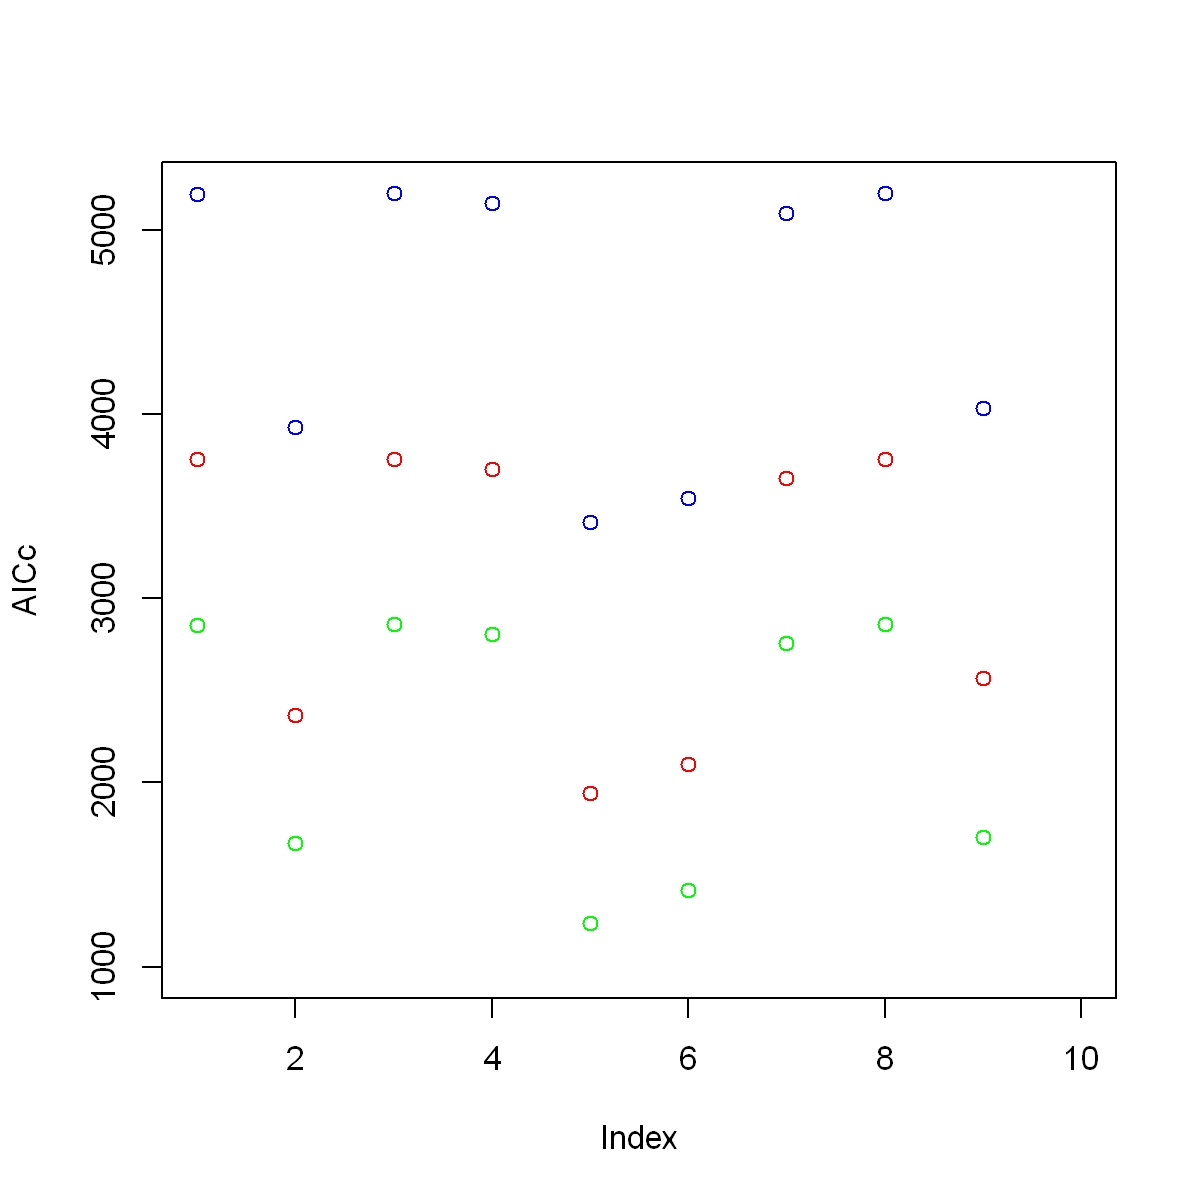

In [114]:
# instead of showing the values in a table, let's make a plot

plot(aicc_table[, "SRL"], col="blue", ylab = "AICc", ylim=c(1000, 5200), xlim = c(1, 10), pch=21)
points(aicc_table[, "RD"], col="green", pch=21)
points(aicc_table[, "RTD"], col="red", pch=21)

# ___`Rphylopars`___
----------------------------

In [118]:
# apparently fitting OU models in brms can be tricky - let's try Rphylopars - which allows multivariate OU models
# the trait data should have species as the first column is also species names, followed by the continuous traits - the name of the first column must be "species"
# with duplicate entries (for within species variation) - we cannot have binominal names as the rownames

fred4 <- read.csv("../../data/chapter2/FRED/subsets/continuous_raw.csv")
fred4 <- fred4[, c("binominal", "F00679", "F00727", "F00709")]
colnames(fred4)[1] = "species"
stopifnot(all(fred4$species %in% tree$tip.label))

head(fred4) # this is also a log transformed and scaled dataset!!!!

,species,F00679,F00727,F00709
,<chr>,<dbl>,<dbl>,<dbl>
1,Larix_gmelinii,0.3194115,32.211568,0.3542858
2,Larix_gmelinii,0.4115552,25.480815,0.2942859
3,Larix_gmelinii,0.5276214,12.980828,0.3828573
4,Larix_gmelinii,0.8469749,6.250067,0.3342859
5,Larix_gmelinii,0.3074501,34.615414,0.3828572
6,Larix_gmelinii,0.4594009,26.442353,0.2600002


In [ ]:
# https://github.com/ericgoolsby/Rphylopars/wiki/Example-4:-Alternative-Evolutionary-Models
# if you run into errors with mvOU models - set usezscores to FALSE as explained in this thread https://github.com/ericgoolsby/Rphylopars/issues/54

In [119]:
# Rphylopars automatically detects multiple within-species observations and estimates within-species covariance with pheno_correlated set to TRUE
# the two fits below account for within species correlations

# with a diagonal alhpa - only phylogenetic correlation between species is accounted for, evolution of traits are treated independently
mvOU_diagonal <- Rphylopars::phylopars(trait_data = fred4, tree = tree, phylo_correlated = TRUE, pheno_correlated = TRUE, model = "mvOU", full_alpha = FALSE, usezscores = FALSE)

# with a full alpha matrix - phylogenetic correlation between species and correlated evolution between traits are accounted for
mvOU_full <- Rphylopars::phylopars(trait_data = fred4, tree = tree, phylo_correlated = TRUE, pheno_correlated = TRUE, model = "mvOU", full_alpha = TRUE, usezscores = FALSE)

In [109]:
stats::AIC(mvOU_diagonal)

[1] 27556.68

In [110]:
stats::AIC(mvOU_full) # full alpha matrix has a lower AIC than the diagonal one - there's evidence to correlation between traits!!!

[1] 27541.39

In [111]:
# now onto models that don't account for within species correlation

mvOU_diagonal_nsp <- Rphylopars::phylopars(trait_data = fred4, tree = tree, phylo_correlated = TRUE, pheno_correlated = FALSE, model = "mvOU", full_alpha = FALSE, usezscores = FALSE)
mvOU_full_nsp <- Rphylopars::phylopars(trait_data = fred4, tree = tree, phylo_correlated = TRUE, pheno_correlated = FALSE, model = "mvOU", full_alpha = TRUE, usezscores = FALSE)

In [112]:
stats::AIC(mvOU_diagonal_nsp) # diagonal is better than full in this case

[1] 33833.58

In [113]:
stats::AIC(mvOU_full_nsp)

[1] 33843.62

In [ ]:
# since the AICs of models that did not account for within species correlation is way higher than the ones that did, there's evidence for within species correlation!!!

In [114]:
# OU model with same rates for all traits - these are not multivariate models (technically??)
# for the OU model, this is like a multivariate OU where the alpha matrix is diagonal and with identical values across the diagonal.

OU_model_base <- Rphylopars::phylopars(trait_data = fred4_v2, tree = tree, phylo_correlated = TRUE, pheno_correlated = TRUE, model = "OU")

In [115]:
stats::AIC(OU_model_base) # AIC higher than our multivariate models

[1] 27555.23